In [1]:
!pip install folium contextily plotly scikit-learn geopandas shapely

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import folium
from folium.plugins import HeatMap
import geopandas as gpd
import contextily as ctx
from shapely import wkt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import plotly.express as px
from scipy.stats import kstest

In [11]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/praktikum_ml/praktikum11/data/katalog_gempa.csv')

Mounted at /content/drive


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92887 entries, 0 to 92886
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   tgl      92887 non-null  object 
 1   ot       92887 non-null  object 
 2   lat      92887 non-null  float64
 3   lon      92887 non-null  float64
 4   depth    92887 non-null  int64  
 5   mag      92887 non-null  float64
 6   remark   92887 non-null  object 
 7   strike1  2735 non-null   float64
 8   dip1     2735 non-null   float64
 9   rake1    2735 non-null   float64
 10  strike2  2735 non-null   float64
 11  dip2     2735 non-null   float64
 12  rake2    2735 non-null   float64
dtypes: float64(9), int64(1), object(3)
memory usage: 9.2+ MB


In [13]:
df.head()

,tgl,ot,lat,lon,depth,mag,remark,strike1,dip1,rake1,strike2,dip2,rake2
0,2008/11/01,21:02:43.058,-9.18,119.06,10,4.9,Sumba Region - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
1,2008/11/01,20:58:50.248,-6.55,129.64,10,4.6,Banda Sea,NaN,NaN,NaN,NaN,NaN,NaN
2,2008/11/01,17:43:12.941,-7.01,106.63,121,3.7,Java - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
3,2008/11/01,16:24:14.755,-3.30,127.85,10,3.2,Seram - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
4,2008/11/01,16:20:37.327,-6.41,129.54,70,4.3,Banda Sea,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df = df.rename(columns={
    'lat': 'latitude',
    'lon': 'longitude'
})

In [15]:
df.isnull().sum()

,0
tgl,0
ot,0
latitude,0
longitude,0
depth,0
mag,0
remark,0
strike1,90152
dip1,90152
rake1,90152


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df = df.drop_duplicates()
df = df.dropna(subset=["latitude", "longitude"])

In [33]:
center_lat = df["latitude"].mean()
center_lon = df["longitude"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=5)
heat_data = df[['latitude','longitude']].values.tolist()
HeatMap(heat_data).add_to(m)
m

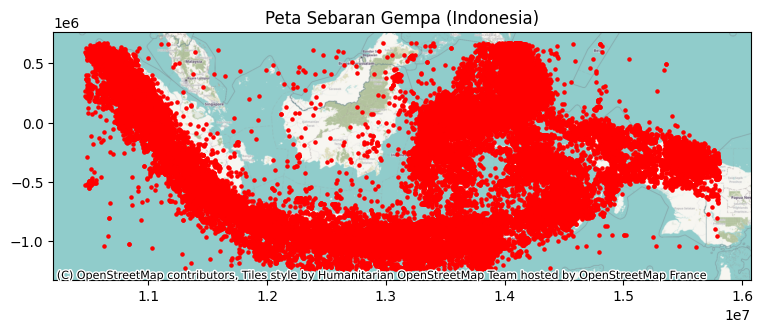

In [20]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)
gdf = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9,9))
gdf.plot(ax=ax, markersize=5, color='red')
ctx.add_basemap(ax, zoom=6)
plt.title("Peta Sebaran Gempa (Indonesia)")
plt.show()

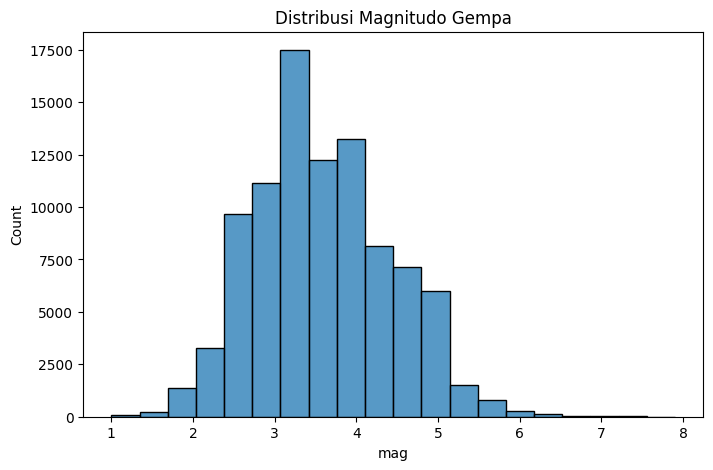

In [36]:
if "mag" in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df["mag"], bins=20)
    plt.title("Distribusi Magnitudo Gempa")
    plt.show()

In [21]:
if "mag" in df.columns:
    numeric = df["mag"].dropna()
    stat, p = kstest(numeric, 'norm')
    print("KS-Statistic:", stat)
    print("p-value:", p)
    print("Kesimpulan:", "Normal" if p > 0.05 else "Tidak Normal")
else:
    print("Tidak ada kolom numerik 'mag'.")

KS-Statistic: 0.9654828823595281
p-value: 0.0
Kesimpulan: Tidak Normal


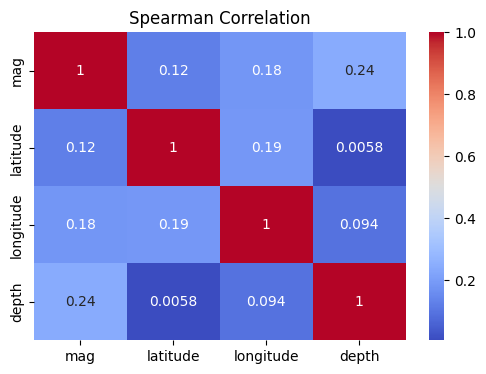

In [22]:
num_cols = ["mag","latitude","longitude","depth"]
available = [c for c in num_cols if c in df.columns]

corr = df[available].corr(method="spearman")

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Spearman Correlation")
plt.show()


In [24]:
X = df[["latitude","longitude"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

db = DBSCAN(eps=0.2, min_samples=5).fit(X_scaled)
df["cluster"] = db.labels_

print(df["cluster"].value_counts())

cluster
 0    92831
-1       30
 1       26
Name: count, dtype: int64


In [25]:
labels = df["cluster"]

if len(set(labels)) > 1 and list(set(labels)) != [-1]:
    filtered = df[df.cluster != -1]
    score = silhouette_score(
        scaler.fit_transform(filtered[["latitude","longitude"]]),
        filtered["cluster"]
    )
    print("Silhouette Score:", score)
else:
    print("Cluster terlalu sedikit untuk silhouette score")

Silhouette Score: 0.2398342046121764


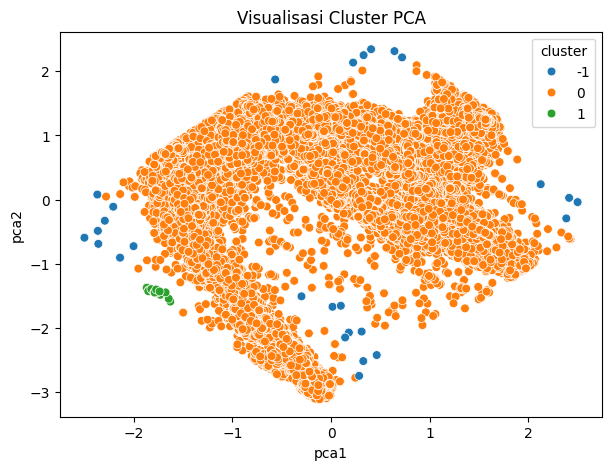

In [26]:
pca = PCA(n_components=2)
df["pca1"] = pca.fit_transform(X_scaled)[:,0]
df["pca2"] = pca.fit_transform(X_scaled)[:,1]

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="pca1", y="pca2", hue="cluster", palette="tab10", s=40)
plt.title("Visualisasi Cluster PCA")
plt.show()

In [27]:
df["cluster_label"] = df["cluster"].apply(
    lambda x: "Noise" if x == -1 else f"Cluster {x}"
)

display(df[["cluster","cluster_label"]].head())

,cluster,cluster_label
0,0,Cluster 0
1,0,Cluster 0
2,0,Cluster 0
3,0,Cluster 0
4,0,Cluster 0


In [28]:
if "mag" in df.columns:
    summary = df.groupby("cluster")["mag"].agg(["count","mean","max","min"])
    display(summary)
else:
    summary = df.groupby("cluster")["latitude"].count()
    display(summary)

,count,mean,max,min
cluster,,,,
-1,30,5.366667,6.5,4.4
0,92831,3.591767,7.9,1.0
1,26,5.192308,7.7,4.6


In [35]:
fig = px.scatter_mapbox(
    df,
    lat="latitude",
    lon="longitude",
    color="cluster",
    size="mag" if "mag" in df.columns else None,
    zoom=3,
    mapbox_style="open-street-map",
    hover_data=df.columns
)
fig.show()

Output hidden; open in https://colab.research.google.com to view.